In [8]:
import torch
import torch.nn as nn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from torch.utils.data import Dataset, DataLoader

In [9]:
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/daily-min-temperatures.csv"
df = pd.read_csv(url)

# Convert temperatures to a 2D float array
raw_data = df['Temp'].values.astype(float).reshape(-1, 1)

# Normalize data to the range (0, 1)
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(raw_data)

In [10]:
class TemperatureDataset(Dataset):
    def __init__(self, data, window_size):
        self.data = data
        self.window_size = window_size

    def __len__(self):
        return len(self.data) - self.window_size

    def __getitem__(self, idx):
        x = self.data[idx : idx + self.window_size]
        y = self.data[idx + self.window_size]
        return torch.tensor(x, dtype=torch.float32), torch.tensor(y, dtype=torch.float32)

# Use a 30-day window to predict the 31st day
WINDOW_SIZE = 30
dataset = TemperatureDataset(scaled_data, WINDOW_SIZE)

# Chronological split instead of random split to mimic real-world deployment
# (Train on the first 85% of history, test on the remaining 15% future days)
train_size = int(len(dataset) * 0.85)
test_size = len(dataset) - train_size

# Manually slice to preserve time order
train_data = torch.utils.data.Subset(dataset, range(0, train_size))
test_data = torch.utils.data.Subset(dataset, range(train_size, len(dataset)))

# DataLoaders - Note: shuffle=False for the test loader to keep time intact for plotting
train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
test_loader = DataLoader(test_data, batch_size=1, shuffle=False)

In [11]:
class TemperatureLSTM(nn.Module):
    def __init__(self, input_size=1, hidden_size=64, num_layers=1, output_size=1):
        super(TemperatureLSTM, self).__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        out, _ = self.lstm(x)
        prediction = self.fc(out[:, -1, :]) # 64-dimensional vector
        return prediction

model = TemperatureLSTM()
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [12]:
epochs = 20
print("Training on Daily Temperature dataset...")

for epoch in range(epochs):
    model.train()
    epoch_loss = 0
    for batch_x, batch_y in train_loader:
        optimizer.zero_grad()
        predictions = model(batch_x)
        loss = criterion(predictions, batch_y)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()

    print(f"Epoch [{epoch+1}/{epochs}], Avg Loss: {epoch_loss/len(train_loader):.5f}")

Training on Daily Temperature dataset...
Epoch [1/20], Avg Loss: 0.05205
Epoch [2/20], Avg Loss: 0.01382
Epoch [3/20], Avg Loss: 0.01172
Epoch [4/20], Avg Loss: 0.01117
Epoch [5/20], Avg Loss: 0.01106
Epoch [6/20], Avg Loss: 0.01108
Epoch [7/20], Avg Loss: 0.01063
Epoch [8/20], Avg Loss: 0.01064
Epoch [9/20], Avg Loss: 0.01058
Epoch [10/20], Avg Loss: 0.01049
Epoch [11/20], Avg Loss: 0.01013
Epoch [12/20], Avg Loss: 0.01016
Epoch [13/20], Avg Loss: 0.00985
Epoch [14/20], Avg Loss: 0.00945
Epoch [15/20], Avg Loss: 0.00949
Epoch [16/20], Avg Loss: 0.00922
Epoch [17/20], Avg Loss: 0.00920
Epoch [18/20], Avg Loss: 0.00882
Epoch [19/20], Avg Loss: 0.00881
Epoch [20/20], Avg Loss: 0.00873


In [13]:
model.eval()
test_predictions = []
test_actuals = []

with torch.no_grad():
    for batch_x, batch_y in test_loader:
        pred = model(batch_x)
        test_predictions.append(pred.item())
        test_actuals.append(batch_y.item())

# Inverse scale back to actual Celsius degrees
test_predictions = scaler.inverse_transform(np.array(test_predictions).reshape(-1, 1))
test_actuals = scaler.inverse_transform(np.array(test_actuals).reshape(-1, 1))

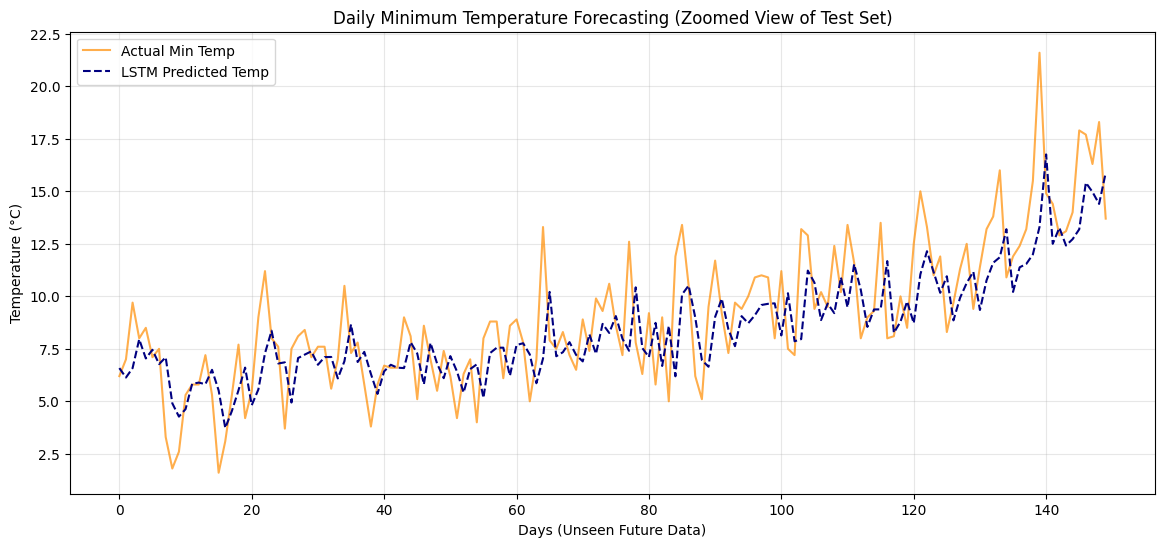

In [14]:
plt.figure(figsize=(14, 6))
# Zooming into the first 150 days of the test set for visual clarity
plt.plot(test_actuals[:150], label="Actual Min Temp", color='darkorange', alpha=0.7)
plt.plot(test_predictions[:150], label="LSTM Predicted Temp", color='navy', linestyle='--')
plt.title("Daily Minimum Temperature Forecasting (Zoomed View of Test Set)")
plt.xlabel("Days (Unseen Future Data)")
plt.ylabel("Temperature (°C)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()